# Parameter Sweeps and Uncertainty Propagation

Model fit parameters (`VV0000`, ...) ride in dedicated kernel inputs, read at
call time — one compiled kernel serves **every** parameter set. That makes
sweeping parameters nearly free of recompilation cost, which is the workload of
uncertainty quantification and of Bayesian parameter estimation with
[ESPEI](https://espei.org) (whose accelerated residuals build on the same
machinery shown here).

The Cu-Mg database used here carries 15 fit parameters (from an ESPEI run).

In [1]:
import time
import warnings
import numpy as np
import matplotlib.pyplot as plt
import pycalphad
from pycalphad import Database, Workspace, calculate, equilibrium, variables as v

# The backend to demonstrate: 'c++' runs generated kernels on the CPU,
# 'gpu' runs the same kernels through CuPy on an NVIDIA or AMD GPU.
BACKEND = 'c++'

def timed(label, fn):
    """Run fn(), print and return (result, elapsed seconds)."""
    start = time.perf_counter()
    result = fn()
    elapsed = time.perf_counter() - start
    print(f'{label}: {elapsed:.1f} s')
    return result, elapsed


In [2]:
from importlib.resources import files
TESTDB = files('pycalphad.tests.databases')
dbf = Database(str(TESTDB / 'cumg_parameters.tdb'))
comps = ['CU', 'MG', 'VA']
phases = sorted(dbf.phases.keys())

# The optimized parameter values (an ESPEI point estimate):
fitted = {'VV0000': -33134.699474175846, 'VV0001': 7734.114029426941,
          'VV0002': -13498.542175596054, 'VV0003': -26555.048975092268,
          'VV0004': 20777.637577083482, 'VV0005': 41915.70425630003,
          'VV0006': -34525.21964215504, 'VV0007': 95457.14639216446,
          'VV0008': 21139.578967453144, 'VV0009': 19047.833726419598,
          'VV0010': 20468.91829601273, 'VV0011': 19601.617855958328,
          'VV0012': -4546.9325861738, 'VV0013': -1640.6354331231278,
          'VV0014': -35682.950005357634}

## `calculate()` with parameter arrays

Both the reference and the backends accept arrays of parameter values in
`calculate()`, adding a `samples` dimension:

In [3]:
rng = np.random.default_rng(42)
n_samples = 64
samples = {k: val * (1 + 0.05 * rng.standard_normal(n_samples)) for k, val in fitted.items()}

ref_c = calculate(dbf, ['CU', 'MG'], ['HCP_A3'], parameters=samples, T=743.15, P=1e5)
with pycalphad.backend(BACKEND):
    acc_c = calculate(dbf, ['CU', 'MG'], ['HCP_A3'], parameters=samples, T=743.15, P=1e5)
d = np.abs(np.asarray(acc_c.GM.values) - np.asarray(ref_c.GM.values))
print(f'{n_samples} parameter sets x {ref_c.GM.values.shape[-1]} sampled points, '
      f'max |dGM|: {np.nanmax(d):.3e} J/mol')

64 parameter sets x 64 sampled points, max |dGM|: 5.457e-11 J/mol


## `equilibrium` over parameter samples

The reference `equilibrium()` takes only scalar parameters — sweeping a
posterior means a Python loop over full equilibrium calls. The accelerated
backends keep everything (kernels, models, grids) cached across parameter sets,
so `pycalphad.gpu.uq.equilibrium_samples` makes the sweep practical: here, 64
posterior-style samples over a 500-condition temperature-composition grid.

In [4]:
from pycalphad.gpu.uq import equilibrium_samples

conditions = {v.N: 1, v.P: 101325, v.T: (620, 1120, 20), v.X('MG'): (0.02, 0.98, 0.05)}

res, t_sweep = timed(f'{n_samples} parameter sets', lambda: equilibrium_samples(
    dbf, comps, phases, conditions, parameters=samples, backend=BACKEND))
print(f'{t_sweep / n_samples * 1000:.0f} ms per full equilibrium grid')
print('result arrays:', {k: getattr(val, 'shape', None) for k, val in res.items()
                          if hasattr(val, 'shape')})

64 parameter sets: 13.7 s
214 ms per full equilibrium grid
result arrays: {'GM': (64, 1, 1, 25, 20), 'MU': (64, 1, 1, 25, 20, 2), 'NP': (64, 1, 1, 25, 20, 3), 'Phase': (64, 1, 1, 25, 20, 3), 'X': (64, 1, 1, 25, 20, 3, 2), 'Y': (64, 1, 1, 25, 20, 3, 4), 'sample_parameters': (64, 15)}


## A probabilistic phase diagram

With equilibria for every parameter set, phase stability becomes a
probability: the fraction of parameter sets under which LIQUID is stable at
each grid point. Boundaries that are well constrained by the fit stay sharp;
uncertain ones blur.

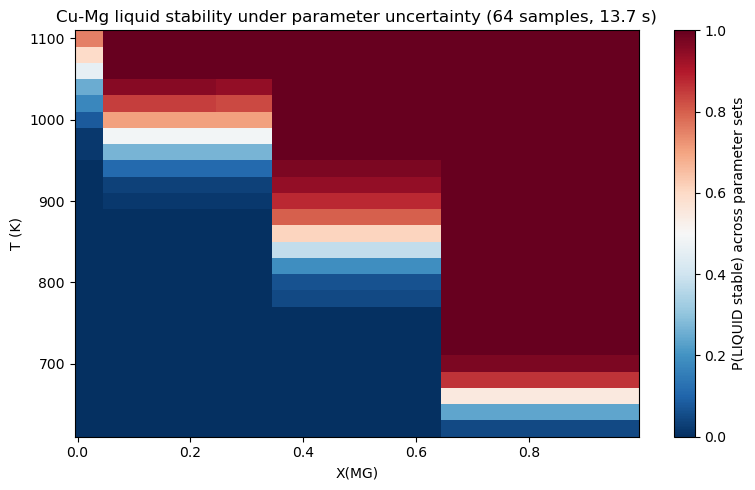

In [5]:
ph = res['Phase']                      # (sample, T, X_MG, vertex)
liquid_stable = (ph == 'LIQUID').any(axis=-1).mean(axis=0)

T_coords = res['grid_coords']['T']
X_coords = res['grid_coords']['X_MG']
fig, ax = plt.subplots(figsize=(8, 5))
im = ax.pcolormesh(X_coords, T_coords, liquid_stable.squeeze(), shading='nearest',
                   cmap='RdBu_r', vmin=0, vmax=1)
fig.colorbar(im, label='P(LIQUID stable) across parameter sets')
ax.set_xlabel('X(MG)'); ax.set_ylabel('T (K)')
ax.set_title(f'Cu-Mg liquid stability under parameter uncertainty '
             f'({n_samples} samples, {t_sweep:.1f} s)')
plt.tight_layout()

For full Bayesian parameter estimation — likelihoods over experimental data,
MCMC ensembles — see ESPEI's accelerated residuals, which batch all four of its
residual types (fixed-configuration thermochemical, equilibrium thermochemical,
activity, and zero-phase-fraction) through these same kernels.